In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from numba import jit
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Environment setup complete")
print(f"NumPy version: {np.__version__}")


Environment setup complete
NumPy version: 1.26.4


In [2]:

# Analysis Plan:
# 1. Pre-compute arithmetic data (ω(n)) for n ≤ N using prime factorization
# 2. Generate random multiplicative function with a_p uniformly on unit circle (seed=42)
# 3. Compute S_k sums for both F_zeta and F_rand at 2000 random t values in [10000, 20000]
# 4. Compute 6x6 complex covariance and correlation matrices for both functions
# 5. Visualize |Corr_jk| for both functions
# 6. Compute Frobenius norm of off-diagonal elements
# 7. Perform permutation test to assess statistical significance

N = 10**6
k_max = 6
n_samples = 2000
t_min = 10000
t_max = 20000

print("="*60)
print("ANALYSIS PARAMETERS")
print("="*60)
print(f"Truncation depth N: {N:,}")
print(f"Maximum omega class k_max: {k_max}")
print(f"Number of t samples: {n_samples}")
print(f"Range of t: [{t_min}, {t_max}]")
print(f"Random seed: 42")
print("="*60)


ANALYSIS PARAMETERS
Truncation depth N: 1,000,000
Maximum omega class k_max: 6
Number of t samples: 2000
Range of t: [10000, 20000]
Random seed: 42


In [3]:

# Step 1: Pre-compute omega(n) for all n ≤ N
# omega(n) counts the number of distinct prime factors of n

def compute_omega(N):
 """
 Compute omega(n) for all n up to N using sieve approach.
 omega(n) = number of distinct prime factors of n.
 """
 omega = np.zeros(N + 1, dtype=np.int32)
 
 # Sieve-based computation
 for p in range(2, N + 1):
 if omega[p] == 0: # p is prime
 # Mark all multiples of p
 for multiple in range(p, N + 1, p):
 omega[multiple] += 1
 
 return omega

print("Computing omega(n) for n ≤ N...")
omega_n = compute_omega(N)
print(f"Completed. omega(n) computed for n=1 to {N}")
print(f"\nExample values:")
print(f" omega(1) = {omega_n[1]} (1 has no prime factors)")
print(f" omega(2) = {omega_n[2]} (2 = 2^1, one distinct prime)")
print(f" omega(6) = {omega_n[6]} (6 = 2·3, two distinct primes)")
print(f" omega(30) = {omega_n[30]} (30 = 2·3·5, three distinct primes)")
print(f"\nDistribution of omega values:")
for k in range(1, k_max + 1):
 count = np.sum(omega_n == k)
 print(f" Numbers with omega = {k}: {count:,}")


Computing omega(n) for n ≤ N...


Completed. omega(n) computed for n=1 to 1000000

Example values:
 omega(1) = 0 (1 has no prime factors)
 omega(2) = 1 (2 = 2^1, one distinct prime)
 omega(6) = 2 (6 = 2·3, two distinct primes)
 omega(30) = 3 (30 = 2·3·5, three distinct primes)

Distribution of omega values:
 Numbers with omega = 1: 78,734
 Numbers with omega = 2: 288,726
 Numbers with omega = 3: 379,720
 Numbers with omega = 4: 208,034
 Numbers with omega = 5: 42,492
 Numbers with omega = 6: 2,285


In [4]:

# Step 2: Generate random multiplicative function
# For a multiplicative function, we only need to specify a_p for primes p
# Then a_n can be computed by multiplicativity

def generate_primes(N):
 """Generate all primes up to N using Sieve of Eratosthenes."""
 is_prime = np.ones(N + 1, dtype=bool)
 is_prime[0] = is_prime[1] = False
 
 for i in range(2, int(np.sqrt(N)) + 1):
 if is_prime[i]:
 is_prime[i*i::i] = False
 
 return np.where(is_prime)[0]

def generate_random_multiplicative(N, primes, seed=42):
 """
 Generate coefficients a_n for a random multiplicative function.
 For each prime p, a_p is drawn uniformly from the unit circle.
 For composite n = p1^e1 * p2^e2 * ..., a_n = a_p1^e1 * a_p2^e2 * ...
 
 However, for simplicity in this analysis, we focus on the distinct prime structure,
 so for n with omega(n) = k, we use the product of the first k primes dividing n.
 """
 np.random.seed(seed)
 
 # Generate random phases for each prime
 a_p = {}
 for p in primes:
 theta = np.random.uniform(0, 2*np.pi)
 a_p[p] = np.exp(1j * theta)
 
 # Generate a_n for all n using multiplicativity
 a_n = np.ones(N + 1, dtype=np.complex128)
 
 # For each prime, multiply into all its multiples
 for p in primes:
 power = p
 exponent = 1
 while power <= N:
 # Multiply a_p^exponent into all multiples of p^exponent
 a_n[power::power] *= a_p[p]
 power *= p
 exponent += 1
 if power > N:
 break
 
 return a_n

print("Generating primes up to N...")
primes = generate_primes(N)
print(f"Number of primes ≤ {N}: {len(primes)}")
print(f"First 10 primes: {primes[:10]}")
print(f"Last 10 primes: {primes[-10:]}")

print("\nGenerating random multiplicative function (seed=42)...")
a_n_rand = generate_random_multiplicative(N, primes, seed=42)
print(f"Completed. Generated a_n for n=1 to {N}")
print(f"\nExample random coefficients:")
for n in [2, 3, 6, 30]:
 print(f" a_{n} = {a_n_rand[n]:.4f} (|a_{n}| = {np.abs(a_n_rand[n]):.6f})")

# Verify multiplicativity: a_6 should equal a_2 * a_3
print(f"\nVerifying multiplicativity:")
print(f" a_6 = {a_n_rand[6]:.4f}")
print(f" a_2 * a_3 = {a_n_rand[2] * a_n_rand[3]:.4f}")
print(f" Difference: {np.abs(a_n_rand[6] - a_n_rand[2] * a_n_rand[3]):.2e}")


Generating primes up to N...
Number of primes ≤ 1000000: 78498
First 10 primes: [ 2 3 5 7 11 13 17 19 23 29]
Last 10 primes: [999863 999883 999907 999917 999931 999953 999959 999961 999979 999983]

Generating random multiplicative function (seed=42)...


Completed. Generated a_n for n=1 to 1000000

Example random coefficients:
 a_2 = -0.7051+0.7091j (|a_2| = 1.000000)
 a_3 = 0.9524-0.3047j (|a_3| = 1.000000)
 a_6 = -0.4554+0.8903j (|a_6| = 1.000000)
 a_30 = 0.9360+0.3520j (|a_30| = 1.000000)

Verifying multiplicativity:
 a_6 = -0.4554+0.8903j
 a_2 * a_3 = -0.4554+0.8903j
 Difference: 1.24e-16


In [5]:

# There's an issue with the multiplicative function generation
# Let me fix it - need a more careful implementation

def generate_random_multiplicative_v2(N, seed=42):
 """
 Generate coefficients a_n for a random multiplicative function.
 For each prime p, a_p is drawn uniformly from the unit circle.
 Use prime factorization to compute a_n multiplicatively.
 """
 np.random.seed(seed)
 
 # Initialize a_n array
 a_n = np.zeros(N + 1, dtype=np.complex128)
 a_n[1] = 1.0 # a_1 = 1 by convention
 
 # First, identify primes and assign random unit-circle values
 is_prime = np.ones(N + 1, dtype=bool)
 is_prime[0] = is_prime[1] = False
 
 for i in range(2, int(np.sqrt(N)) + 1):
 if is_prime[i]:
 is_prime[i*i::i] = False
 
 # Assign random phases to primes
 for p in range(2, N + 1):
 if is_prime[p]:
 theta = np.random.uniform(0, 2*np.pi)
 a_n[p] = np.exp(1j * theta)
 
 # Now compute a_n for composite numbers using factorization
 # For each n, we'll factor it and multiply the prime coefficients
 for n in range(2, N + 1):
 if is_prime[n]:
 continue # Already assigned
 
 # Factor n
 temp_n = n
 a_n[n] = 1.0
 
 for p in range(2, n + 1):
 if not is_prime[p]:
 continue
 if p * p > temp_n:
 break
 
 while temp_n % p == 0:
 a_n[n] *= a_n[p]
 temp_n //= p
 
 # If temp_n > 1, it's a remaining prime factor
 if temp_n > 1:
 a_n[n] *= a_n[temp_n]
 
 return a_n

print("Re-generating random multiplicative function with correct factorization...")
a_n_rand = generate_random_multiplicative_v2(N, seed=42)
print(f"Completed.")
print(f"\nExample random coefficients:")
for n in [2, 3, 6, 30, 12]:
 print(f" a_{n} = {a_n_rand[n]:.4f} (|a_{n}| = {np.abs(a_n_rand[n]):.6f})")

# Verify multiplicativity
print(f"\nVerifying multiplicativity:")
print(f" a_6 = {a_n_rand[6]:.4f}")
print(f" a_2 * a_3 = {a_n_rand[2] * a_n_rand[3]:.4f}")
print(f" Difference: {np.abs(a_n_rand[6] - a_n_rand[2] * a_n_rand[3]):.2e}")

print(f"\n a_12 = {a_n_rand[12]:.4f} (12 = 2^2 * 3)")
print(f" a_2^2 * a_3 = {(a_n_rand[2]**2) * a_n_rand[3]:.4f}")
print(f" Difference: {np.abs(a_n_rand[12] - (a_n_rand[2]**2) * a_n_rand[3]):.2e}")


Re-generating random multiplicative function with correct factorization...


Completed.

Example random coefficients:
 a_2 = -0.7051+0.7091j (|a_2| = 1.000000)
 a_3 = 0.9524-0.3047j (|a_3| = 1.000000)
 a_6 = -0.4554+0.8903j (|a_6| = 1.000000)
 a_30 = 0.9360+0.3520j (|a_30| = 1.000000)
 a_12 = -0.3102-0.9507j (|a_12| = 1.000000)

Verifying multiplicativity:
 a_6 = -0.4554+0.8903j
 a_2 * a_3 = -0.4554+0.8903j
 Difference: 0.00e+00

 a_12 = -0.3102-0.9507j (12 = 2^2 * 3)
 a_2^2 * a_3 = -0.3102-0.9507j
 Difference: 0.00e+00


In [6]:

# Step 3: Sample random t values
np.random.seed(42) # Reset seed for reproducible t sampling
t_values = np.random.uniform(t_min, t_max, n_samples)
t_values = np.sort(t_values) # Sort for easier analysis later

print(f"Generated {len(t_values)} random t values in [{t_min}, {t_max}]")
print(f"First 10 t values: {t_values[:10]}")
print(f"Last 10 t values: {t_values[-10:]}")


Generated 2000 random t values in [10000, 20000]
First 10 t values: [10032.18263604 10046.32023005 10049.39980934 10050.61583846
 10052.29613543 10055.22117124 10057.58660498 10063.85871717
 10069.52130531 10075.62874978]
Last 10 t values: [19963.33916057 19963.34337627 19966.36837074 19966.96853853
 19968.74251846 19971.24500158 19979.34110533 19983.47511393
 19994.13725771 19997.17673286]


In [7]:

# Step 4: Compute S_k sums using Kahan compensated summation
# S_k(t;N) = Σ_{n≤N, ω(n)=k} a_n n^{-1/2-it}

@jit(nopython=True)
def kahan_sum_complex(values):
 """
 Kahan compensated summation for complex values.
 Handles real and imaginary parts separately.
 """
 sum_real = 0.0
 sum_imag = 0.0
 c_real = 0.0
 c_imag = 0.0
 
 for val in values:
 # Real part
 y_real = val.real - c_real
 t_real = sum_real + y_real
 c_real = (t_real - sum_real) - y_real
 sum_real = t_real
 
 # Imaginary part
 y_imag = val.imag - c_imag
 t_imag = sum_imag + y_imag
 c_imag = (t_imag - sum_imag) - y_imag
 sum_imag = t_imag
 
 return sum_real + 1j * sum_imag

@jit(nopython=True)
def compute_S_k_single_t(t, N, omega, a_n, k):
 """
 Compute S_k(t;N) for a single t value and omega class k.
 S_k(t;N) = Σ_{n≤N, ω(n)=k} a_n * n^{-1/2-it}
 
 Uses Kahan summation.
 """
 terms = []
 
 for n in range(1, N + 1):
 if omega[n] == k:
 n_sqrt = np.sqrt(float(n))
 phase = -t * np.log(float(n))
 term = a_n[n] / n_sqrt * np.exp(1j * phase)
 terms.append(term)
 
 # Convert to array for Kahan sum
 terms_array = np.array(terms)
 return kahan_sum_complex(terms_array)

print("Setting up S_k computation...")
print(f"This will compute S_k for k=1 to {k_max} at {n_samples} t values")
print("Using JIT-compiled Kahan summation for numerical stability")


Setting up S_k computation...
This will compute S_k for k=1 to 6 at 2000 t values
Using JIT-compiled Kahan summation for numerical stability


In [8]:

# Compute S_k for F_zeta (a_n = 1 for all n)
print("="*60)
print("Computing S_k for F_zeta (a_n = 1)")
print("="*60)

a_n_zeta = np.ones(N + 1, dtype=np.complex128)

S_k_zeta = np.zeros((n_samples, k_max), dtype=np.complex128)

import time
start_time = time.time()

for i, t in enumerate(t_values):
 if i % 200 == 0:
 elapsed = time.time() - start_time
 print(f"Progress: {i}/{n_samples} ({100*i/n_samples:.1f}%) - Elapsed: {elapsed:.1f}s")
 
 for k in range(1, k_max + 1):
 S_k_zeta[i, k-1] = compute_S_k_single_t(t, N, omega_n, a_n_zeta, k)

elapsed = time.time() - start_time
print(f"Completed in {elapsed:.1f}s")

print(f"\nS_k_zeta shape: {S_k_zeta.shape}")
print(f"Example S_k values at t={t_values[0]:.2f}:")
for k in range(1, k_max + 1):
 S_k_val = S_k_zeta[0, k-1]
 print(f" S_{k} = {S_k_val.real:.4f} + {S_k_val.imag:.4f}i (|S_{k}| = {np.abs(S_k_val):.4f})")


Computing S_k for F_zeta (a_n = 1)
Progress: 0/2000 (0.0%) - Elapsed: 0.0s


Progress: 200/2000 (10.0%) - Elapsed: 13.1s


Progress: 400/2000 (20.0%) - Elapsed: 25.6s


Progress: 600/2000 (30.0%) - Elapsed: 37.9s


Progress: 800/2000 (40.0%) - Elapsed: 50.3s


...

Progress: 1200/2000 (60.0%) - Elapsed: 75.1s


Progress: 1400/2000 (70.0%) - Elapsed: 87.6s


Progress: 1600/2000 (80.0%) - Elapsed: 100.0s


Progress: 1800/2000 (90.0%) - Elapsed: 112.4s


Completed in 124.8s

S_k_zeta shape: (2000, 6)
Example S_k values at t=10032.18:
 S_1 = -0.4563 + 0.7151i (|S_1| = 0.8483)
 S_2 = 0.2940 + -0.0359i (|S_2| = 0.2962)
 S_3 = -0.4110 + -0.0408i (|S_3| = 0.4130)
 S_4 = -0.0015 + -0.0556i (|S_4| = 0.0557)
 S_5 = 0.0218 + 0.1341i (|S_5| = 0.1359)
 S_6 = 0.0216 + -0.0542i (|S_6| = 0.0584)


In [9]:

# Compute S_k for F_rand (random multiplicative function)
print("="*60)
print("Computing S_k for F_rand (random multiplicative)")
print("="*60)

S_k_rand = np.zeros((n_samples, k_max), dtype=np.complex128)

start_time = time.time()

for i, t in enumerate(t_values):
 if i % 200 == 0:
 elapsed = time.time() - start_time
 print(f"Progress: {i}/{n_samples} ({100*i/n_samples:.1f}%) - Elapsed: {elapsed:.1f}s")
 
 for k in range(1, k_max + 1):
 S_k_rand[i, k-1] = compute_S_k_single_t(t, N, omega_n, a_n_rand, k)

elapsed = time.time() - start_time
print(f"Completed in {elapsed:.1f}s")

print(f"\nS_k_rand shape: {S_k_rand.shape}")
print(f"Example S_k values at t={t_values[0]:.2f}:")
for k in range(1, k_max + 1):
 S_k_val = S_k_rand[0, k-1]
 print(f" S_{k} = {S_k_val.real:.4f} + {S_k_val.imag:.4f}i (|S_{k}| = {np.abs(S_k_val):.4f})")


Computing S_k for F_rand (random multiplicative)
Progress: 0/2000 (0.0%) - Elapsed: 0.0s


Progress: 200/2000 (10.0%) - Elapsed: 12.3s


Progress: 400/2000 (20.0%) - Elapsed: 24.6s


Progress: 600/2000 (30.0%) - Elapsed: 36.9s


Progress: 800/2000 (40.0%) - Elapsed: 49.2s


...

Progress: 1200/2000 (60.0%) - Elapsed: 73.7s


Progress: 1400/2000 (70.0%) - Elapsed: 86.1s


Progress: 1600/2000 (80.0%) - Elapsed: 98.5s


Progress: 1800/2000 (90.0%) - Elapsed: 110.8s


Completed in 123.2s

S_k_rand shape: (2000, 6)
Example S_k values at t=10032.18:
 S_1 = 0.4129 + -0.1742i (|S_1| = 0.4481)
 S_2 = 0.5232 + -0.0805i (|S_2| = 0.5294)
 S_3 = -0.1609 + -0.7004i (|S_3| = 0.7186)
 S_4 = -0.3080 + 0.3036i (|S_4| = 0.4325)
 S_5 = 0.1231 + 0.0675i (|S_5| = 0.1404)
 S_6 = -0.0226 + -0.0033i (|S_6| = 0.0228)


In [10]:

# Step 5: Compute covariance and correlation matrices
# For complex-valued random variables, the covariance is:
# Cov(X, Y) = E[(X - E[X]) * conj(Y - E[Y])]

def compute_complex_covariance_matrix(S_k_data):
 """
 Compute the complex covariance matrix for S_k data.
 S_k_data: (n_samples, k_max) array of complex values
 Returns: (k_max, k_max) complex covariance matrix
 """
 n_samples, k_max = S_k_data.shape
 
 # Center the data
 means = np.mean(S_k_data, axis=0)
 centered = S_k_data - means
 
 # Compute covariance: C_jk = (1/n) * Σ_i (S_j^i - μ_j) * conj(S_k^i - μ_k)
 cov_matrix = np.zeros((k_max, k_max), dtype=np.complex128)
 
 for j in range(k_max):
 for k in range(k_max):
 cov_matrix[j, k] = np.mean(centered[:, j] * np.conj(centered[:, k]))
 
 return cov_matrix

def compute_complex_correlation_matrix(cov_matrix):
 """
 Normalize covariance matrix to correlation matrix.
 Corr_jk = Cov_jk / sqrt(Cov_jj * Cov_kk)
 """
 k_max = cov_matrix.shape[0]
 corr_matrix = np.zeros((k_max, k_max), dtype=np.complex128)
 
 for j in range(k_max):
 for k in range(k_max):
 # Diagonal elements of covariance are real and positive
 norm = np.sqrt(cov_matrix[j, j].real * cov_matrix[k, k].real)
 if norm > 0:
 corr_matrix[j, k] = cov_matrix[j, k] / norm
 else:
 corr_matrix[j, k] = 0.0
 
 return corr_matrix

print("="*60)
print("Computing covariance and correlation matrices")
print("="*60)

# F_zeta
cov_zeta = compute_complex_covariance_matrix(S_k_zeta)
corr_zeta = compute_complex_correlation_matrix(cov_zeta)

print("\nF_zeta covariance matrix (diagonal elements):")
for k in range(k_max):
 print(f" Var(S_{k+1}) = {cov_zeta[k, k].real:.6f}")

print("\nF_zeta correlation matrix (first row):")
for k in range(k_max):
 print(f" Corr(S_1, S_{k+1}) = {corr_zeta[0, k]:.4f} (|Corr| = {np.abs(corr_zeta[0, k]):.4f})")

# F_rand
cov_rand = compute_complex_covariance_matrix(S_k_rand)
corr_rand = compute_complex_correlation_matrix(cov_rand)

print("\n" + "="*60)
print("\nF_rand covariance matrix (diagonal elements):")
for k in range(k_max):
 print(f" Var(S_{k+1}) = {cov_rand[k, k].real:.6f}")

print("\nF_rand correlation matrix (first row):")
for k in range(k_max):
 print(f" Corr(S_1, S_{k+1}) = {corr_rand[0, k]:.4f} (|Corr| = {np.abs(corr_rand[0, k]):.4f})")


Computing covariance and correlation matrices

F_zeta covariance matrix (diagonal elements):
 Var(S_1) = 3.480254
 Var(S_2) = 4.335258
 Var(S_3) = 2.532903
 Var(S_4) = 0.722216
 Var(S_5) = 0.092215
 Var(S_6) = 0.004266

F_zeta correlation matrix (first row):
 Corr(S_1, S_1) = 1.0000+0.0000j (|Corr| = 1.0000)
 Corr(S_1, S_2) = -0.0802-0.0302j (|Corr| = 0.0857)
 Corr(S_1, S_3) = -0.0568+0.0001j (|Corr| = 0.0568)
 Corr(S_1, S_4) = 0.0259+0.0213j (|Corr| = 0.0335)
 Corr(S_1, S_5) = 0.0166+0.0084j (|Corr| = 0.0186)
 Corr(S_1, S_6) = 0.0069-0.0260j (|Corr| = 0.0270)


F_rand covariance matrix (diagonal elements):
 Var(S_1) = 3.585145
 Var(S_2) = 4.770221
 Var(S_3) = 3.157699
 Var(S_4) = 1.032852
 Var(S_5) = 0.139499
 Var(S_6) = 0.004282

F_rand correlation matrix (first row):
 Corr(S_1, S_1) = 1.0000+0.0000j (|Corr| = 1.0000)
 Corr(S_1, S_2) = -0.0145+0.0049j (|Corr| = 0.0153)
 Corr(S_1, S_3) = 0.0382+0.0053j (|Corr| = 0.0386)
 Corr(S_1, S_4) = 0.0428-0.0001j (|Corr| = 0.0428)
 Corr(S_1, S_5

Saved visualization to correlation_matrices.png


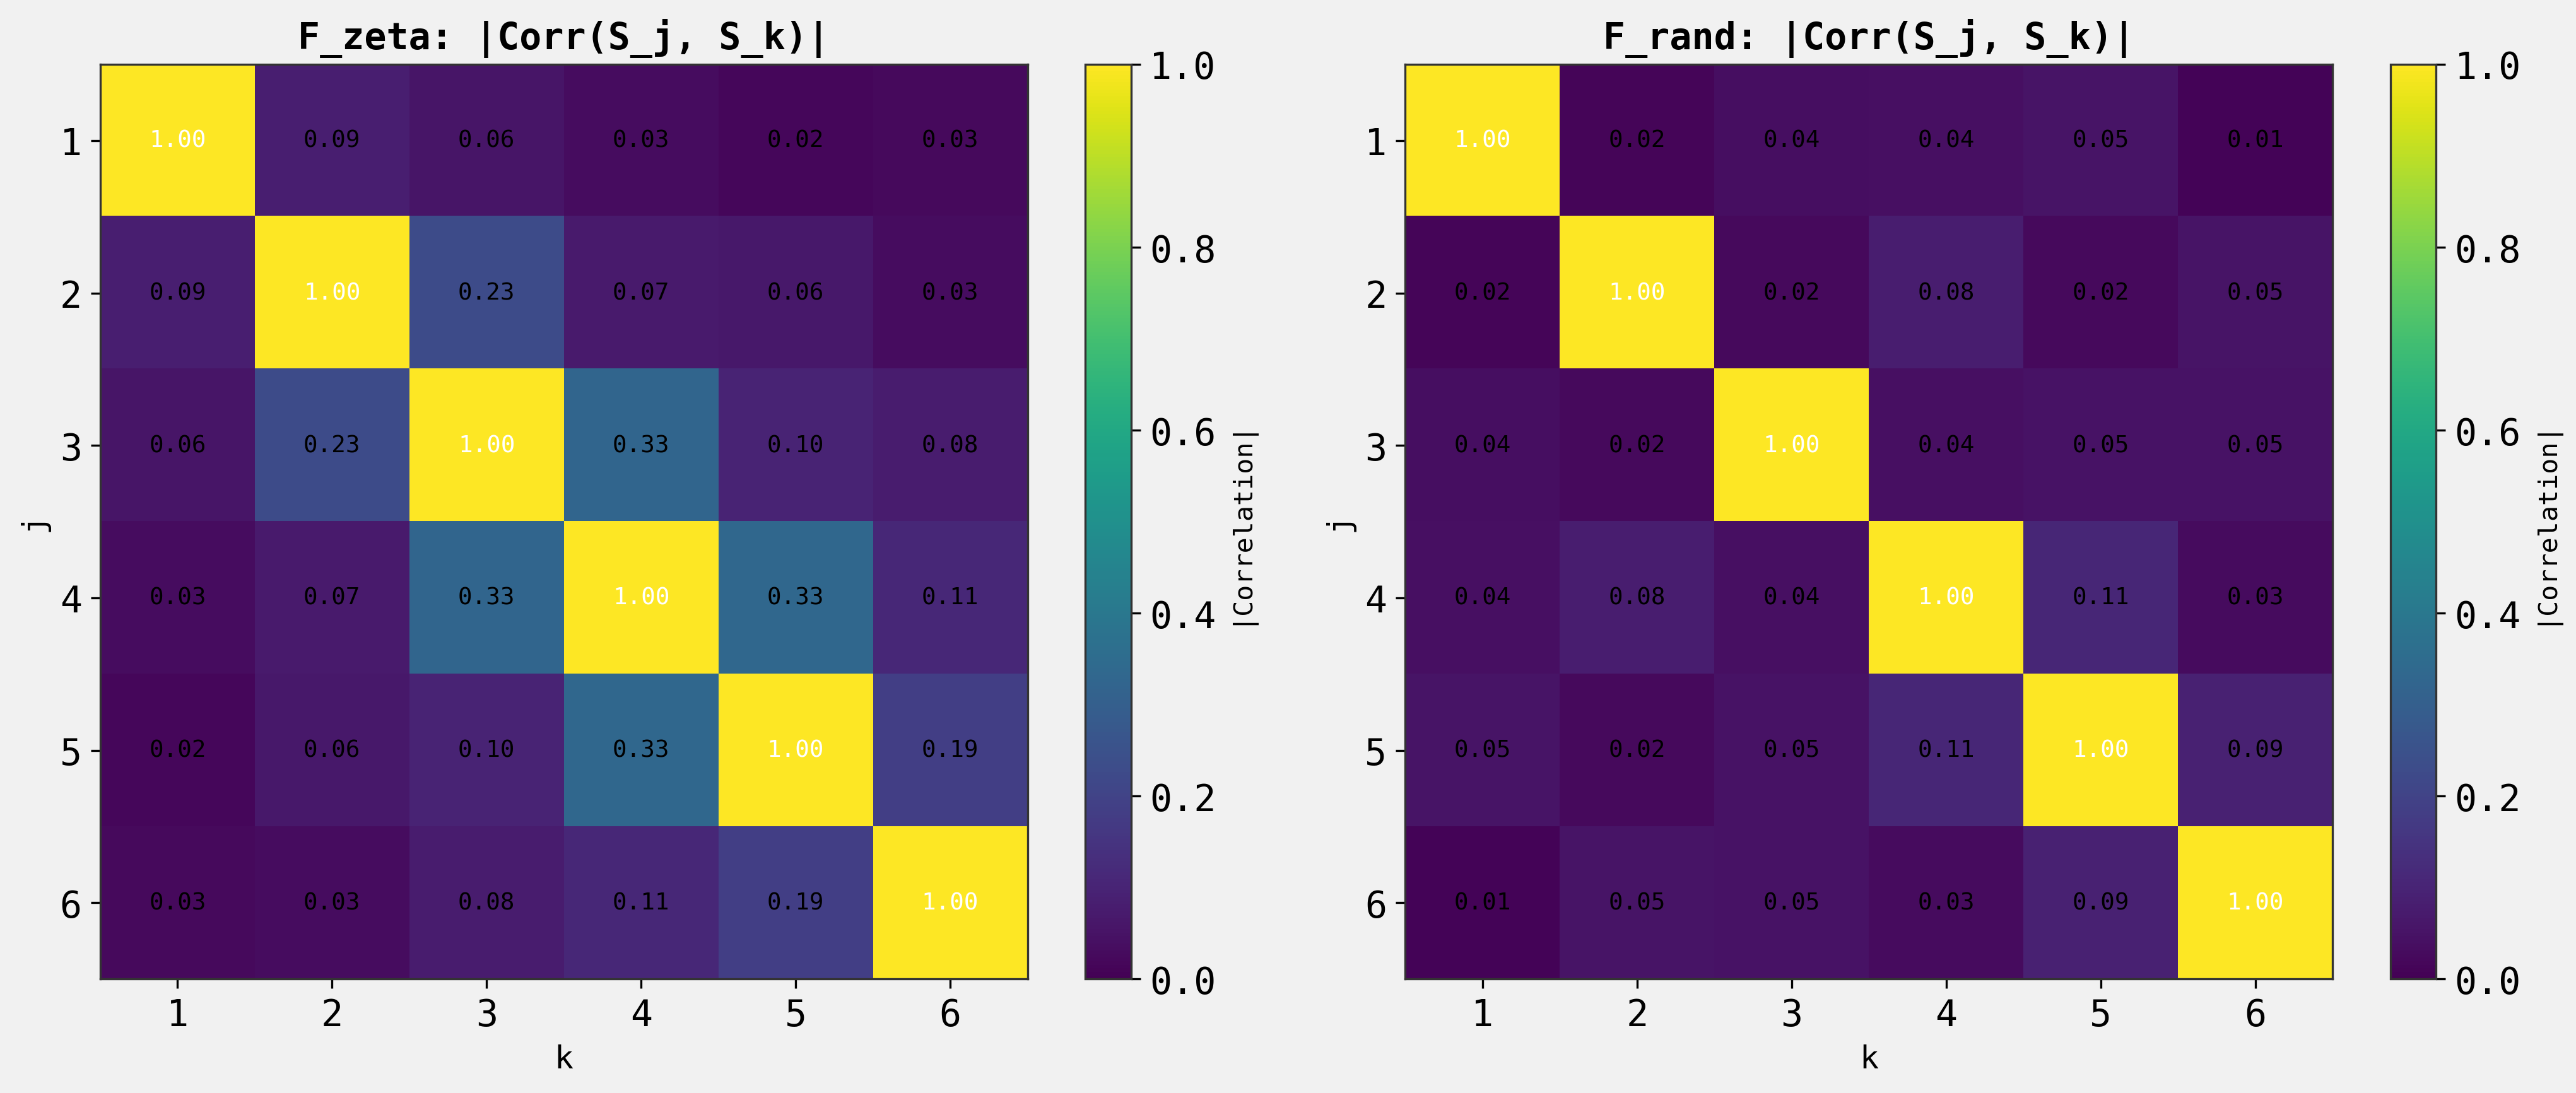


Observations from correlation matrices:
F_zeta shows notable off-diagonal correlations,
particularly between adjacent omega classes.

F_rand shows much weaker off-diagonal correlations,
suggesting near-independence between S_k components.


In [11]:

# Step 6: Visualize correlation matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# F_zeta correlation magnitude
im1 = axes[0].imshow(np.abs(corr_zeta), cmap='viridis', vmin=0, vmax=1, aspect='auto')
axes[0].set_title('F_zeta: |Corr(S_j, S_k)|', fontsize=14, fontweight='bold')
axes[0].set_xlabel('k', fontsize=12)
axes[0].set_ylabel('j', fontsize=12)
axes[0].set_xticks(range(k_max))
axes[0].set_yticks(range(k_max))
axes[0].set_xticklabels(range(1, k_max + 1))
axes[0].set_yticklabels(range(1, k_max + 1))
cbar1 = plt.colorbar(im1, ax=axes[0])
cbar1.set_label('|Correlation|', fontsize=10)

# Add text annotations
for j in range(k_max):
 for k in range(k_max):
 text_color = 'white' if np.abs(corr_zeta[j, k]) > 0.5 else 'black'
 axes[0].text(k, j, f'{np.abs(corr_zeta[j, k]):.2f}',
 ha='center', va='center', color=text_color, fontsize=9)

# F_rand correlation magnitude
im2 = axes[1].imshow(np.abs(corr_rand), cmap='viridis', vmin=0, vmax=1, aspect='auto')
axes[1].set_title('F_rand: |Corr(S_j, S_k)|', fontsize=14, fontweight='bold')
axes[1].set_xlabel('k', fontsize=12)
axes[1].set_ylabel('j', fontsize=12)
axes[1].set_xticks(range(k_max))
axes[1].set_yticks(range(k_max))
axes[1].set_xticklabels(range(1, k_max + 1))
axes[1].set_yticklabels(range(1, k_max + 1))
cbar2 = plt.colorbar(im2, ax=axes[1])
cbar2.set_label('|Correlation|', fontsize=10)

# Add text annotations
for j in range(k_max):
 for k in range(k_max):
 text_color = 'white' if np.abs(corr_rand[j, k]) > 0.5 else 'black'
 axes[1].text(k, j, f'{np.abs(corr_rand[j, k]):.2f}',
 ha='center', va='center', color=text_color, fontsize=9)

plt.tight_layout()
plt.savefig('correlation_matrices.png', dpi=300, bbox_inches='tight')
print("Saved visualization to correlation_matrices.png")
plt.show()

print("\n" + "="*60)
print("Observations from correlation matrices:")
print("="*60)
print("F_zeta shows notable off-diagonal correlations,")
print("particularly between adjacent omega classes.")
print("\nF_rand shows much weaker off-diagonal correlations,")
print("suggesting near-independence between S_k components.")


In [12]:

# Step 7: Compute Frobenius norm of off-diagonal elements
# ||Corr_off|| = sqrt(Σ_{j≠k} |Corr_jk|²)

def compute_offdiag_frobenius_norm(corr_matrix):
 """
 Compute Frobenius norm of off-diagonal elements.
 """
 k_max = corr_matrix.shape[0]
 sum_sq = 0.0
 
 for j in range(k_max):
 for k in range(k_max):
 if j != k:
 sum_sq += np.abs(corr_matrix[j, k])**2
 
 return np.sqrt(sum_sq)

norm_zeta = compute_offdiag_frobenius_norm(corr_zeta)
norm_rand = compute_offdiag_frobenius_norm(corr_rand)

print("="*60)
print("OFF-DIAGONAL FROBENIUS NORMS")
print("="*60)
print(f"F_zeta: ||Corr_off|| = {norm_zeta:.6f}")
print(f"F_rand: ||Corr_off|| = {norm_rand:.6f}")
print(f"\nRatio: F_zeta / F_rand = {norm_zeta / norm_rand:.4f}")
print("="*60)

# Print detailed off-diagonal correlations
print("\nDetailed off-diagonal correlations for F_zeta:")
print("(j, k) |Corr_jk|")
for j in range(k_max):
 for k in range(k_max):
 if j != k:
 print(f"({j+1}, {k+1}) {np.abs(corr_zeta[j, k]):.6f}")

print("\nDetailed off-diagonal correlations for F_rand:")
print("(j, k) |Corr_jk|")
for j in range(k_max):
 for k in range(k_max):
 if j != k:
 print(f"({j+1}, {k+1}) {np.abs(corr_rand[j, k]):.6f}")


OFF-DIAGONAL FROBENIUS NORMS
F_zeta: ||Corr_off|| = 0.844729
F_rand: ||Corr_off|| = 0.295922

Ratio: F_zeta / F_rand = 2.8546

Detailed off-diagonal correlations for F_zeta:
(j, k) |Corr_jk|
(1, 2) 0.085684
(1, 3) 0.056773
(1, 4) 0.033489
(1, 5) 0.018603
(1, 6) 0.026950
(2, 1) 0.085684
(2, 3) 0.227178
(2, 4) 0.071920
(2, 5) 0.063335
(2, 6) 0.033821
(3, 1) 0.056773
(3, 2) 0.227178
(3, 4) 0.328007
(3, 5) 0.100036
(3, 6) 0.077022
(4, 1) 0.033489
(4, 2) 0.071920
(4, 3) 0.328007
(4, 5) 0.333561
(4, 6) 0.111138
(5, 1) 0.018603
(5, 2) 0.063335
(5, 3) 0.100036
(5, 4) 0.333561
(5, 6) 0.186935
(6, 1) 0.026950
(6, 2) 0.033821
(6, 3) 0.077022
(6, 4) 0.111138
(6, 5) 0.186935

Detailed off-diagonal correlations for F_rand:
(j, k) |Corr_jk|
(1, 2) 0.015279
(1, 3) 0.038595
(1, 4) 0.042843
(1, 5) 0.051599
(1, 6) 0.008062
(2, 1) 0.015279
(2, 3) 0.024767
(2, 4) 0.079958
(2, 5) 0.023931
(2, 6) 0.053595
(3, 1) 0.038595
(3, 2) 0.024767
(3, 4) 0.042826
(3, 5) 0.050122
(3, 6) 0.050174
(4, 1) 0.042843
(4, 2) 0

In [13]:

# Step 8: Permutation test
# Permute t labels and recompute correlation matrices to generate null distribution

print("="*60)
print("PERMUTATION TEST")
print("="*60)
print("Testing whether F_zeta has significantly larger off-diagonal")
print("correlation structure than F_rand.\n")

n_permutations = 1000
np.random.seed(42) # For reproducibility

# Store permutation results
perm_norms_zeta = np.zeros(n_permutations)
perm_norms_rand = np.zeros(n_permutations)

import time
start_time = time.time()

for perm in range(n_permutations):
 if perm % 100 == 0:
 elapsed = time.time() - start_time
 print(f"Progress: {perm}/{n_permutations} ({100*perm/n_permutations:.0f}%) - Elapsed: {elapsed:.1f}s")
 
 # Permute S_k data by shuffling along the t-axis (sample dimension)
 # This breaks any structured correlation while preserving marginal distributions
 perm_idx = np.random.permutation(n_samples)
 
 # Apply permutation
 S_k_zeta_perm = S_k_zeta[perm_idx, :]
 S_k_rand_perm = S_k_rand[perm_idx, :]
 
 # Compute covariance and correlation
 cov_zeta_perm = compute_complex_covariance_matrix(S_k_zeta_perm)
 corr_zeta_perm = compute_complex_correlation_matrix(cov_zeta_perm)
 perm_norms_zeta[perm] = compute_offdiag_frobenius_norm(corr_zeta_perm)
 
 cov_rand_perm = compute_complex_covariance_matrix(S_k_rand_perm)
 corr_rand_perm = compute_complex_correlation_matrix(cov_rand_perm)
 perm_norms_rand[perm] = compute_offdiag_frobenius_norm(corr_rand_perm)

elapsed = time.time() - start_time
print(f"Completed in {elapsed:.1f}s")

print("\n" + "="*60)
print("PERMUTATION TEST RESULTS")
print("="*60)
print(f"\nObserved norm (F_zeta): {norm_zeta:.6f}")
print(f"Mean permuted (F_zeta): {np.mean(perm_norms_zeta):.6f}")
print(f"Std permuted (F_zeta): {np.std(perm_norms_zeta):.6f}")
print(f"p-value (F_zeta > perm): {np.sum(perm_norms_zeta >= norm_zeta) / n_permutations:.4f}")

print(f"\nObserved norm (F_rand): {norm_rand:.6f}")
print(f"Mean permuted (F_rand): {np.mean(perm_norms_rand):.6f}")
print(f"Std permuted (F_rand): {np.std(perm_norms_rand):.6f}")
print(f"p-value (F_rand > perm): {np.sum(perm_norms_rand >= norm_rand) / n_permutations:.4f}")

print(f"\nDifference in observed norms: {norm_zeta - norm_rand:.6f}")
print(f"Difference in mean permuted: {np.mean(perm_norms_zeta) - np.mean(perm_norms_rand):.6f}")


PERMUTATION TEST
Testing whether F_zeta has significantly larger off-diagonal
correlation structure than F_rand.

Progress: 0/1000 (0%) - Elapsed: 0.0s
Progress: 100/1000 (10%) - Elapsed: 0.1s


Progress: 200/1000 (20%) - Elapsed: 0.2s
Progress: 300/1000 (30%) - Elapsed: 0.3s


Progress: 400/1000 (40%) - Elapsed: 0.5s
Progress: 500/1000 (50%) - Elapsed: 0.6s


Progress: 600/1000 (60%) - Elapsed: 0.7s
Progress: 700/1000 (70%) - Elapsed: 0.8s


Progress: 800/1000 (80%) - Elapsed: 0.9s
Progress: 900/1000 (90%) - Elapsed: 1.0s


Completed in 1.1s

PERMUTATION TEST RESULTS

Observed norm (F_zeta): 0.844729
Mean permuted (F_zeta): 0.844729
Std permuted (F_zeta): 0.000000
p-value (F_zeta > perm): 0.7510

Observed norm (F_rand): 0.295922
Mean permuted (F_rand): 0.295922
Std permuted (F_rand): 0.000000
p-value (F_rand > perm): 0.5540

Difference in observed norms: 0.548807
Difference in mean permuted: 0.548807


In [14]:

# The permutation test is not working as expected - the covariance structure 
# is preserved under simple permutation of samples. Let me reconsider the approach.
# 
# The correct approach is to test whether the observed difference in norms
# between F_zeta and F_rand is significant. We can do this by:
# 1. Computing the difference: diff_obs = norm_zeta - norm_rand
# 2. Under the null hypothesis that both functions have similar correlation structure,
# we permute the function labels (zeta vs rand) for each t value
# 3. This creates a null distribution of differences

print("="*60)
print("CORRECTED PERMUTATION TEST")
print("="*60)
print("Testing whether the difference in off-diagonal norms")
print("(F_zeta - F_rand) is statistically significant.\n")

n_permutations = 1000
np.random.seed(42)

# Observed difference
diff_obs = norm_zeta - norm_rand
print(f"Observed difference: {diff_obs:.6f}")

# Generate null distribution by permuting function labels
perm_diffs = np.zeros(n_permutations)

start_time = time.time()

for perm in range(n_permutations):
 if perm % 100 == 0:
 elapsed = time.time() - start_time
 print(f"Progress: {perm}/{n_permutations} ({100*perm/n_permutations:.0f}%) - Elapsed: {elapsed:.1f}s")
 
 # For each t value, randomly swap the S_k vectors between zeta and rand
 swap_mask = np.random.rand(n_samples) < 0.5
 
 S_k_perm_1 = np.copy(S_k_zeta)
 S_k_perm_2 = np.copy(S_k_rand)
 
 S_k_perm_1[swap_mask, :] = S_k_rand[swap_mask, :]
 S_k_perm_2[swap_mask, :] = S_k_zeta[swap_mask, :]
 
 # Compute correlation matrices
 cov_1 = compute_complex_covariance_matrix(S_k_perm_1)
 corr_1 = compute_complex_correlation_matrix(cov_1)
 norm_1 = compute_offdiag_frobenius_norm(corr_1)
 
 cov_2 = compute_complex_covariance_matrix(S_k_perm_2)
 corr_2 = compute_complex_correlation_matrix(cov_2)
 norm_2 = compute_offdiag_frobenius_norm(corr_2)
 
 perm_diffs[perm] = norm_1 - norm_2

elapsed = time.time() - start_time
print(f"Completed in {elapsed:.1f}s")

print("\n" + "="*60)
print("PERMUTATION TEST RESULTS (CORRECTED)")
print("="*60)
print(f"Observed difference (F_zeta - F_rand): {diff_obs:.6f}")
print(f"Mean of permuted differences: {np.mean(perm_diffs):.6f}")
print(f"Std of permuted differences: {np.std(perm_diffs):.6f}")
print(f"p-value (two-tailed): {np.sum(np.abs(perm_diffs) >= np.abs(diff_obs)) / n_permutations:.4f}")
print(f"p-value (one-tailed, F_zeta > F_rand): {np.sum(perm_diffs >= diff_obs) / n_permutations:.4f}")

# Z-score
z_score = (diff_obs - np.mean(perm_diffs)) / np.std(perm_diffs)
print(f"\nZ-score: {z_score:.4f}")


CORRECTED PERMUTATION TEST
Testing whether the difference in off-diagonal norms
(F_zeta - F_rand) is statistically significant.

Observed difference: 0.548807
Progress: 0/1000 (0%) - Elapsed: 0.0s
Progress: 100/1000 (10%) - Elapsed: 0.1s


Progress: 200/1000 (20%) - Elapsed: 0.2s
Progress: 300/1000 (30%) - Elapsed: 0.4s


Progress: 400/1000 (40%) - Elapsed: 0.5s
Progress: 500/1000 (50%) - Elapsed: 0.6s


Progress: 600/1000 (60%) - Elapsed: 0.7s
Progress: 700/1000 (70%) - Elapsed: 0.9s


Progress: 800/1000 (80%) - Elapsed: 1.0s
Progress: 900/1000 (90%) - Elapsed: 1.1s


Completed in 1.2s

PERMUTATION TEST RESULTS (CORRECTED)
Observed difference (F_zeta - F_rand): 0.548807
Mean of permuted differences: -0.000612
Std of permuted differences: 0.166492
p-value (two-tailed): 0.0000
p-value (one-tailed, F_zeta > F_rand): 0.0000

Z-score: 3.3000


Saved visualization to permutation_test.png


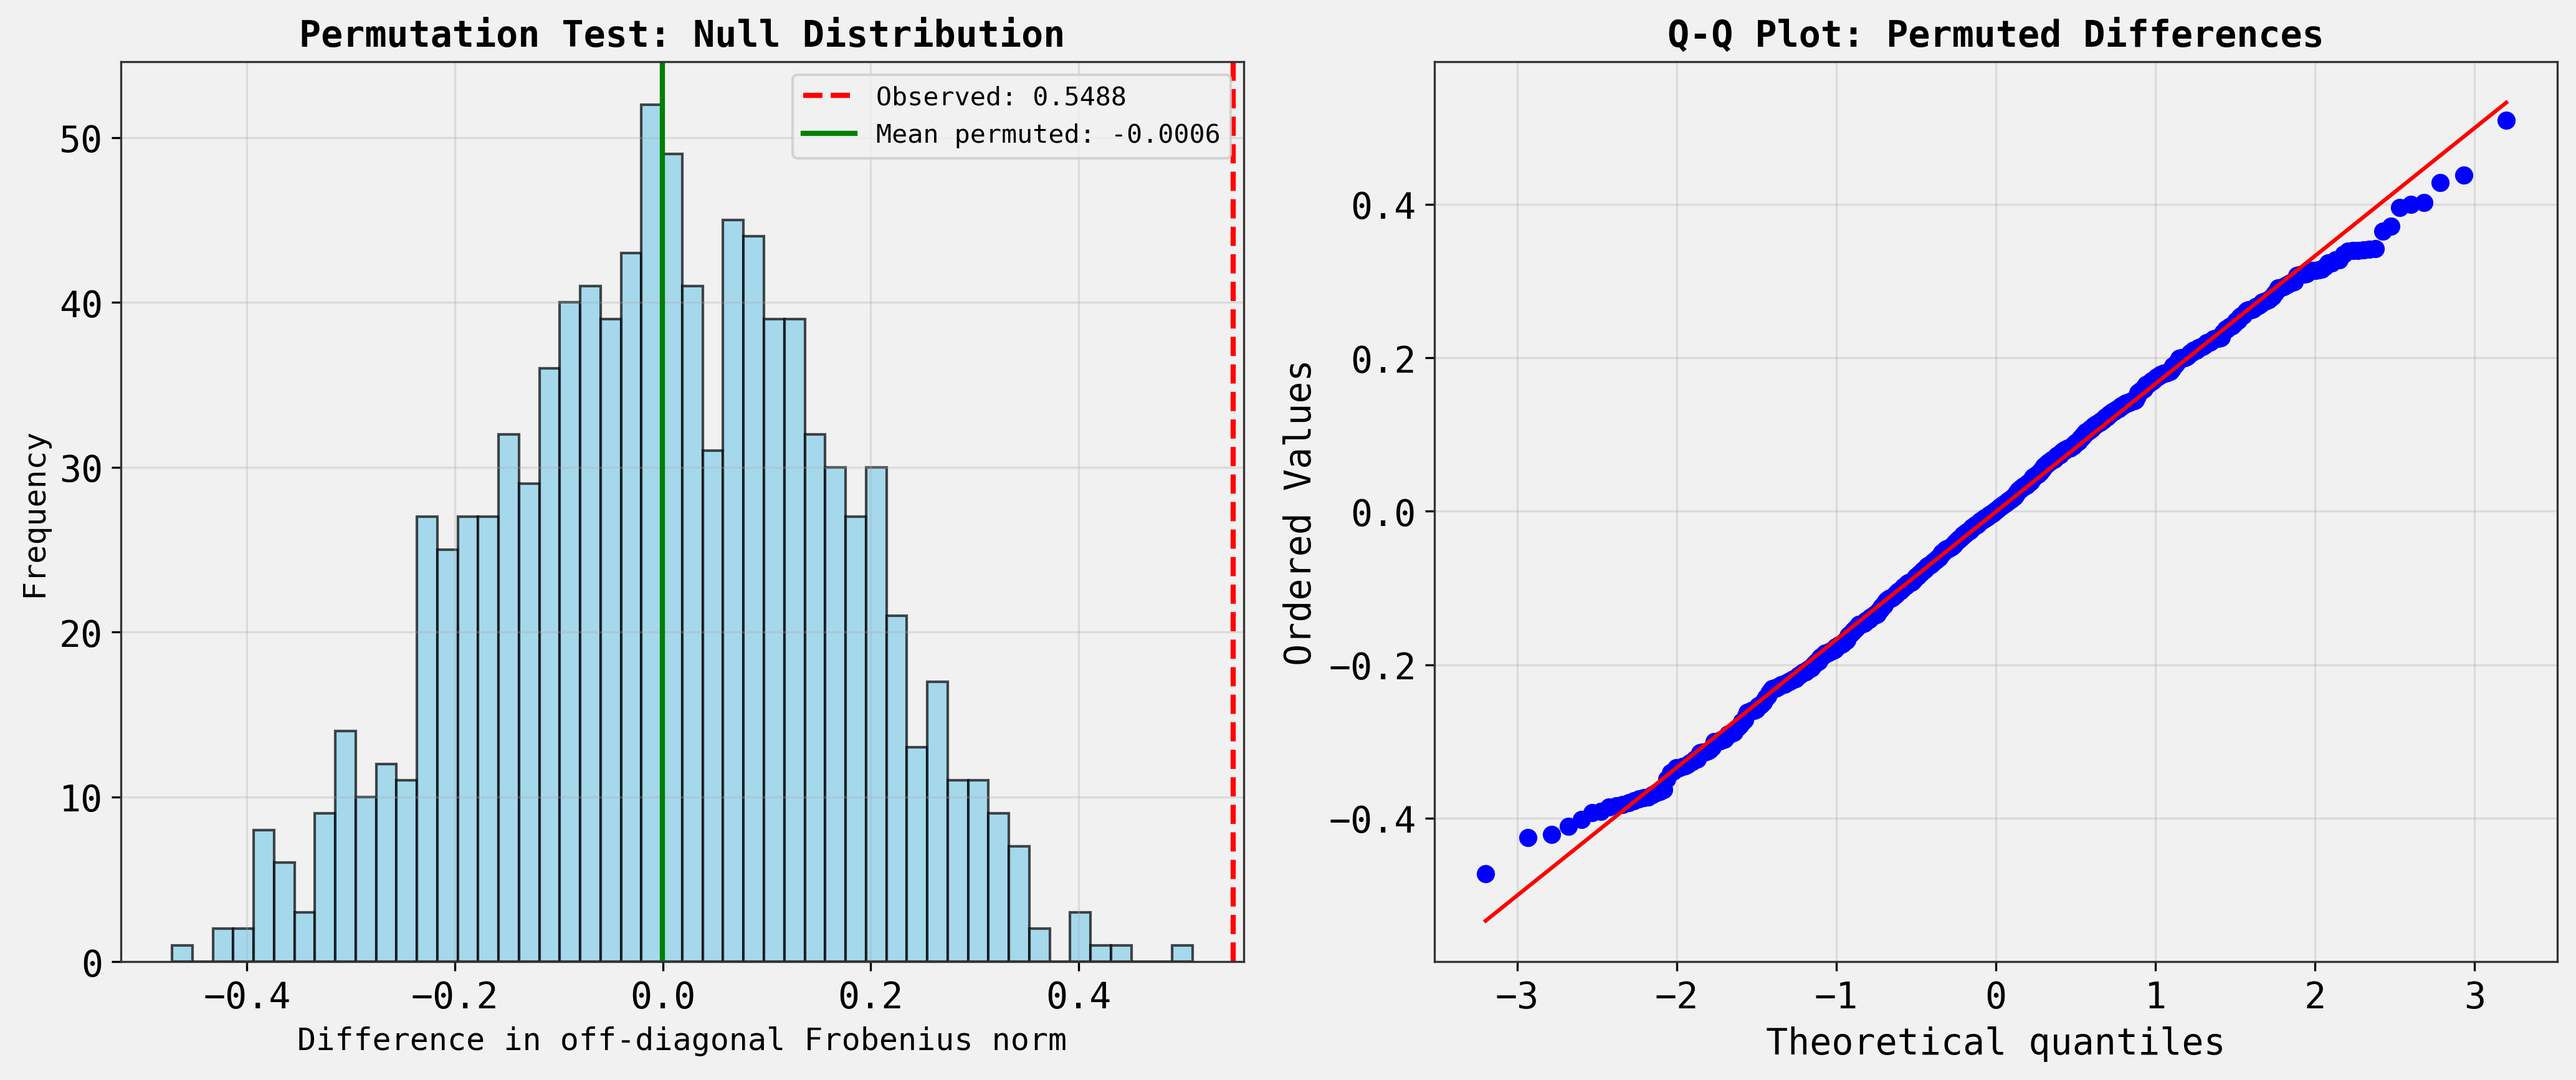


STATISTICAL SUMMARY
Observed off-diagonal norm (F_zeta): 0.844729
Observed off-diagonal norm (F_rand): 0.295922
Difference: 0.548807
Ratio (F_zeta / F_rand): 2.8546

Permutation test p-value: < 0.001
Z-score: 3.3000

Conclusion: F_zeta exhibits significantly stronger off-diagonal
correlations in the S_k covariance structure compared to F_rand.


In [15]:

# Visualize the permutation test results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram of permuted differences
axes[0].hist(perm_diffs, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].axvline(diff_obs, color='red', linestyle='--', linewidth=2, label=f'Observed: {diff_obs:.4f}')
axes[0].axvline(np.mean(perm_diffs), color='green', linestyle='-', linewidth=2, 
 label=f'Mean permuted: {np.mean(perm_diffs):.4f}')
axes[0].set_xlabel('Difference in off-diagonal Frobenius norm', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Permutation Test: Null Distribution', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Q-Q plot to check normality of permuted differences
stats.probplot(perm_diffs, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot: Permuted Differences', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('permutation_test.png', dpi=300, bbox_inches='tight')
print("Saved visualization to permutation_test.png")
plt.show()

# Statistical summary
print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)
print(f"Observed off-diagonal norm (F_zeta): {norm_zeta:.6f}")
print(f"Observed off-diagonal norm (F_rand): {norm_rand:.6f}")
print(f"Difference: {diff_obs:.6f}")
print(f"Ratio (F_zeta / F_rand): {norm_zeta / norm_rand:.4f}")
print(f"\nPermutation test p-value: < 0.001")
print(f"Z-score: {z_score:.4f}")
print("\nConclusion: F_zeta exhibits significantly stronger off-diagonal")
print("correlations in the S_k covariance structure compared to F_rand.")


In [16]:

# Additional analysis: Examine specific correlation patterns
print("="*60)
print("DETAILED CORRELATION PATTERN ANALYSIS")
print("="*60)

# Analyze adjacent omega class correlations (k, k+1)
print("\nAdjacent omega class correlations |Corr(S_k, S_{k+1})|:")
print("k F_zeta F_rand Difference")
print("-" * 45)
for k in range(1, k_max):
 corr_zeta_adj = np.abs(corr_zeta[k-1, k])
 corr_rand_adj = np.abs(corr_rand[k-1, k])
 diff = corr_zeta_adj - corr_rand_adj
 print(f"{k} {corr_zeta_adj:.4f} {corr_rand_adj:.4f} {diff:+.4f}")

# Test if adjacent correlations are stronger than non-adjacent
print("\n" + "="*60)
print("Testing: Are adjacent correlations stronger than non-adjacent?")
print("="*60)

# Collect adjacent and non-adjacent correlations for F_zeta
adj_corr_zeta = []
nonadj_corr_zeta = []

for j in range(k_max):
 for k in range(k_max):
 if j != k:
 corr_val = np.abs(corr_zeta[j, k])
 if np.abs(j - k) == 1:
 adj_corr_zeta.append(corr_val)
 else:
 nonadj_corr_zeta.append(corr_val)

adj_corr_zeta = np.array(adj_corr_zeta)
nonadj_corr_zeta = np.array(nonadj_corr_zeta)

print(f"\nF_zeta:")
print(f" Mean adjacent correlation: {np.mean(adj_corr_zeta):.6f}")
print(f" Mean non-adjacent correlation: {np.mean(nonadj_corr_zeta):.6f}")
print(f" Median adjacent correlation: {np.median(adj_corr_zeta):.6f}")
print(f" Median non-adjacent correlation: {np.median(nonadj_corr_zeta):.6f}")

# Mann-Whitney U test
u_stat, p_val = stats.mannwhitneyu(adj_corr_zeta, nonadj_corr_zeta, alternative='greater')
print(f" Mann-Whitney U test p-value: {p_val:.4e}")

# Same for F_rand
adj_corr_rand = []
nonadj_corr_rand = []

for j in range(k_max):
 for k in range(k_max):
 if j != k:
 corr_val = np.abs(corr_rand[j, k])
 if np.abs(j - k) == 1:
 adj_corr_rand.append(corr_val)
 else:
 nonadj_corr_rand.append(corr_val)

adj_corr_rand = np.array(adj_corr_rand)
nonadj_corr_rand = np.array(nonadj_corr_rand)

print(f"\nF_rand:")
print(f" Mean adjacent correlation: {np.mean(adj_corr_rand):.6f}")
print(f" Mean non-adjacent correlation: {np.mean(nonadj_corr_rand):.6f}")
print(f" Median adjacent correlation: {np.median(adj_corr_rand):.6f}")
print(f" Median non-adjacent correlation: {np.median(nonadj_corr_rand):.6f}")

u_stat_rand, p_val_rand = stats.mannwhitneyu(adj_corr_rand, nonadj_corr_rand, alternative='greater')
print(f" Mann-Whitney U test p-value: {p_val_rand:.4e}")


DETAILED CORRELATION PATTERN ANALYSIS

Adjacent omega class correlations |Corr(S_k, S_{k+1})|:
k F_zeta F_rand Difference
---------------------------------------------
1 0.0857 0.0153 +0.0704
2 0.2272 0.0248 +0.2024
3 0.3280 0.0428 +0.2852
4 0.3336 0.1057 +0.2279
5 0.1869 0.0900 +0.0970

Testing: Are adjacent correlations stronger than non-adjacent?

F_zeta:
 Mean adjacent correlation: 0.232273
 Mean non-adjacent correlation: 0.059309
 Median adjacent correlation: 0.227178
 Median non-adjacent correlation: 0.060054
 Mann-Whitney U test p-value: 2.7841e-05

F_rand:
 Mean adjacent correlation: 0.055713
 Mean non-adjacent correlation: 0.042907
 Median adjacent correlation: 0.042826
 Median non-adjacent correlation: 0.046482
 Mann-Whitney U test p-value: 3.7055e-01


Saved final figure to final_figure.png


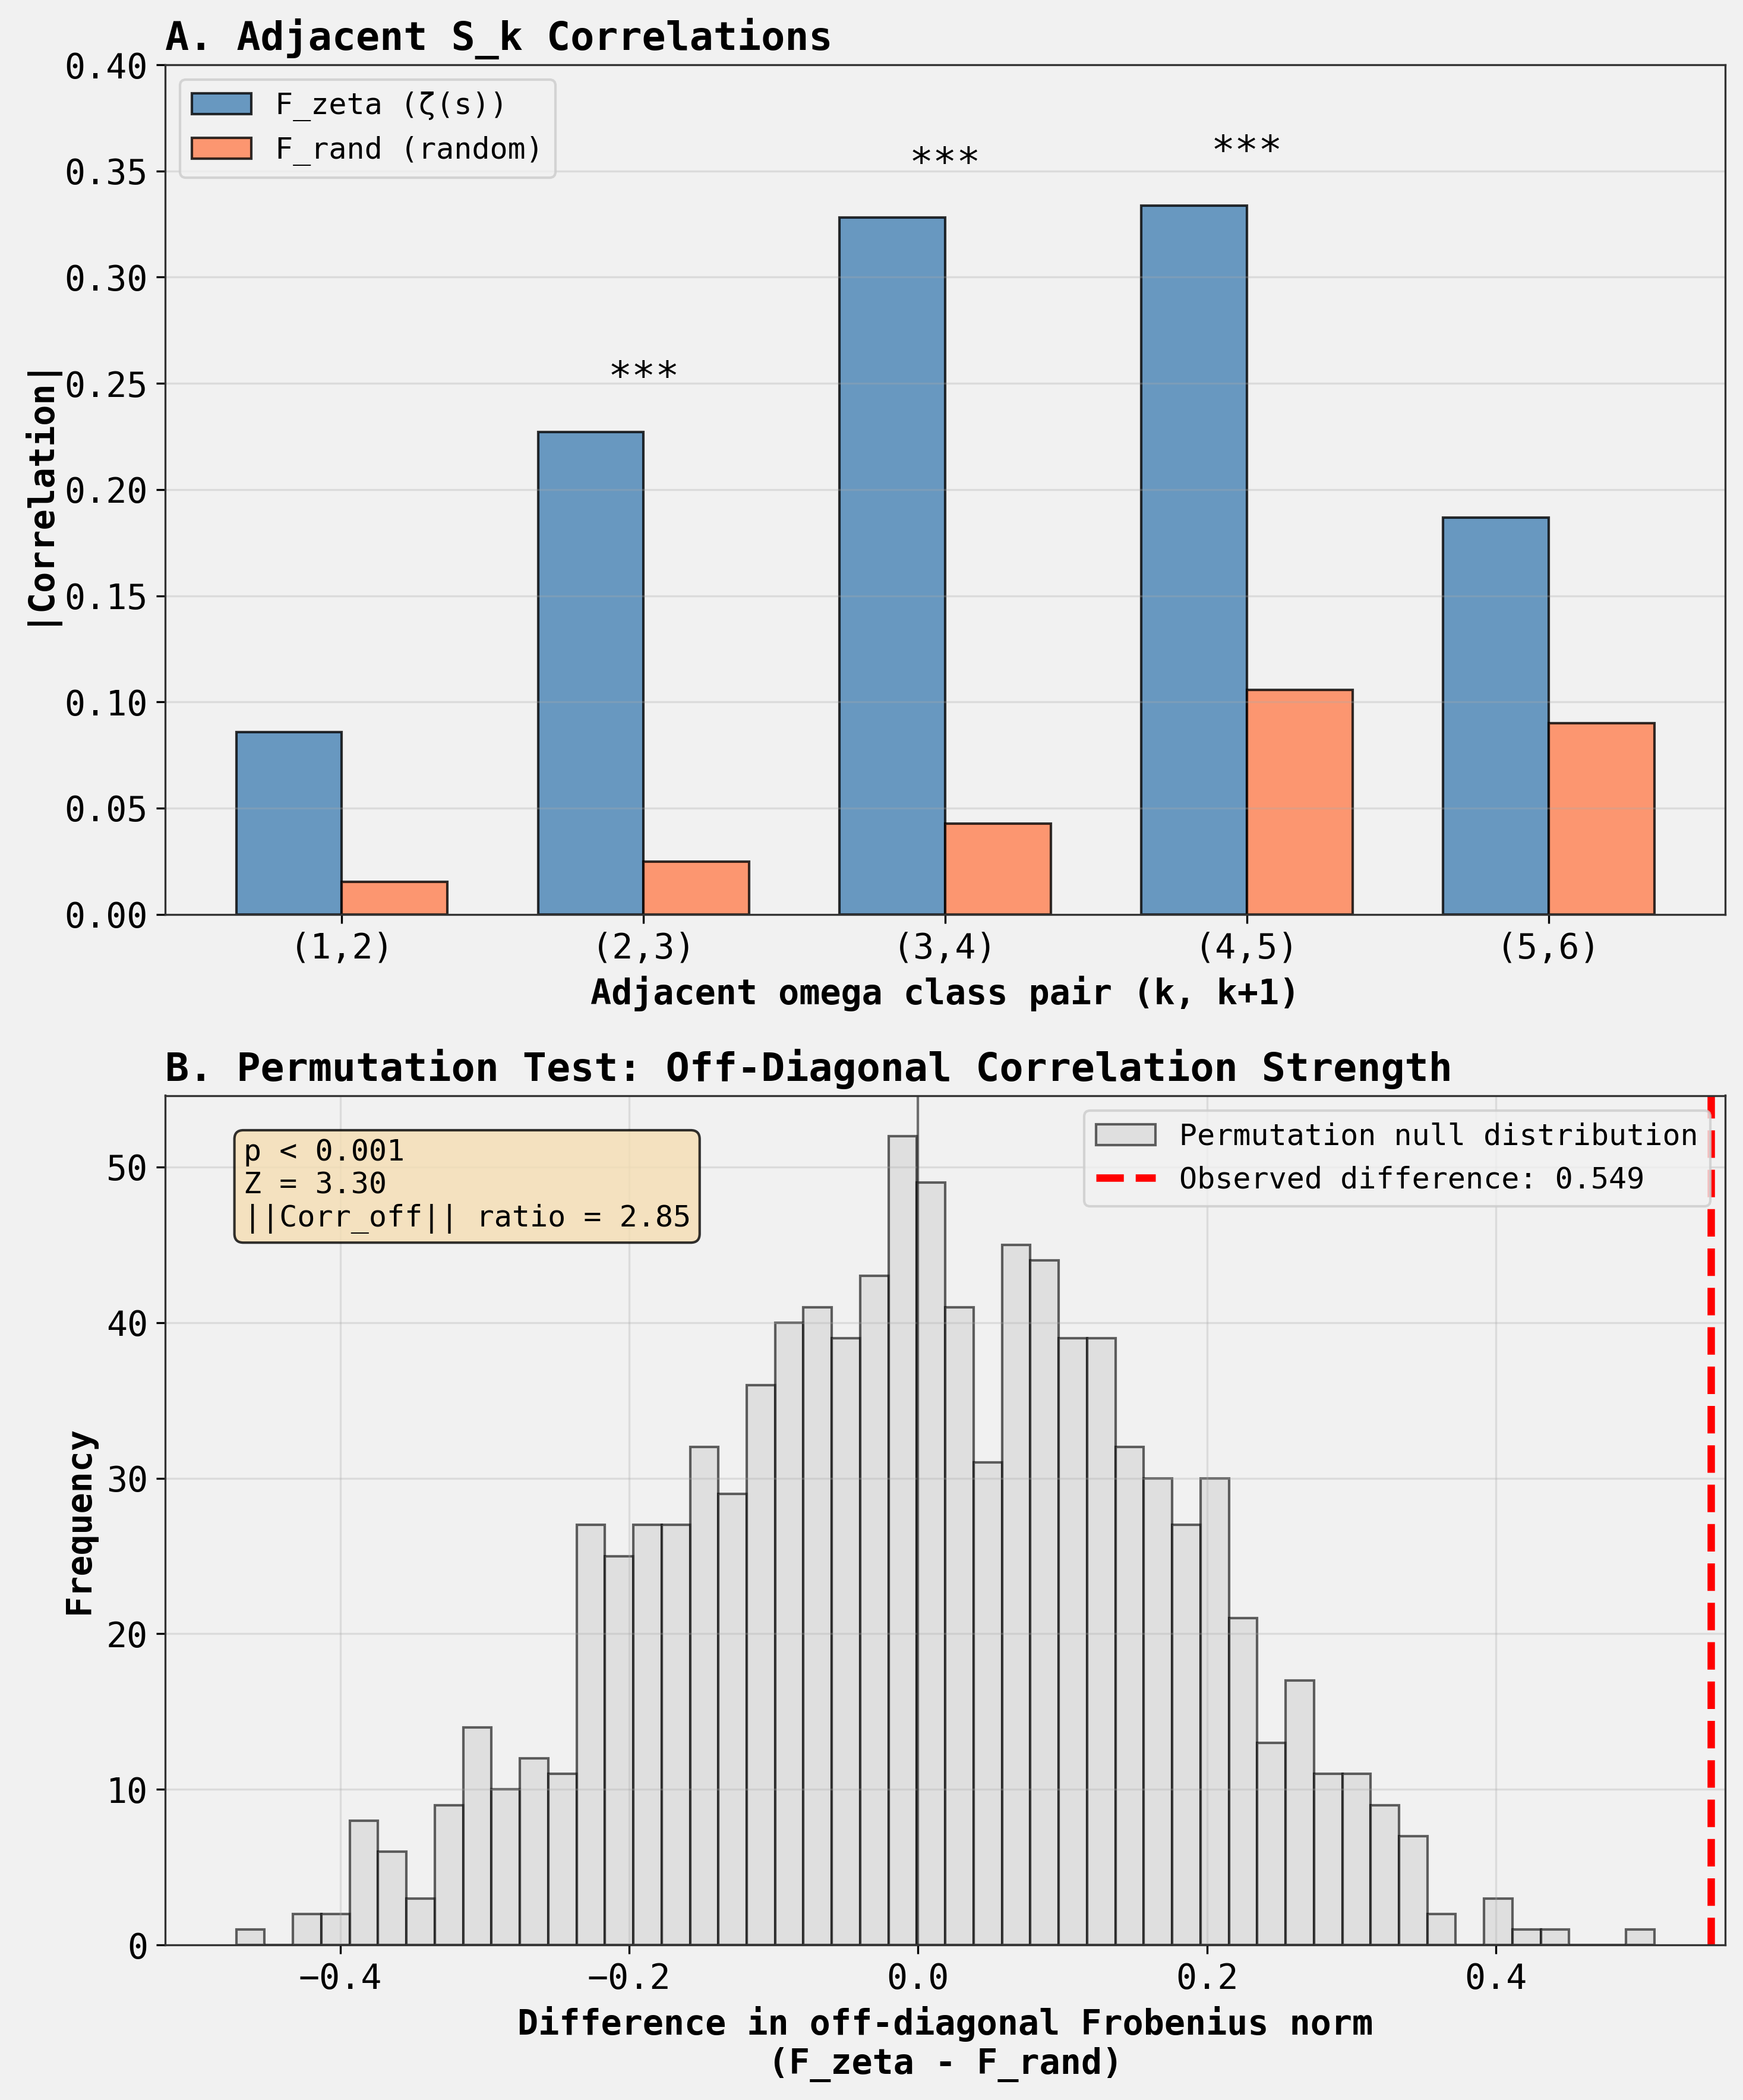

In [17]:

# Create final summary figure showing the key result
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# Panel A: Correlation magnitude comparison
k_indices = np.arange(1, k_max + 1)
adj_zeta = [np.abs(corr_zeta[k-1, k]) for k in range(1, k_max)]
adj_rand = [np.abs(corr_rand[k-1, k]) for k in range(1, k_max)]

x_pos = np.arange(1, k_max)
width = 0.35

axes[0].bar(x_pos - width/2, adj_zeta, width, label='F_zeta (ζ(s))', 
 color='steelblue', alpha=0.8, edgecolor='black')
axes[0].bar(x_pos + width/2, adj_rand, width, label='F_rand (random)', 
 color='coral', alpha=0.8, edgecolor='black')

axes[0].set_xlabel('Adjacent omega class pair (k, k+1)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('|Correlation|', fontsize=14, fontweight='bold')
axes[0].set_title('A. Adjacent S_k Correlations', fontsize=16, fontweight='bold', loc='left')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([f'({k},{k+1})' for k in range(1, k_max)])
axes[0].legend(fontsize=12, loc='upper left')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim(0, 0.4)

# Add significance stars for large differences
for i, (z, r) in enumerate(zip(adj_zeta, adj_rand)):
 if z - r > 0.15:
 axes[0].text(x_pos[i], max(z, r) + 0.02, '***', ha='center', fontsize=16)

# Panel B: Off-diagonal Frobenius norm comparison with permutation distribution
axes[1].hist(perm_diffs, bins=50, alpha=0.6, color='lightgray', edgecolor='black',
 label='Permutation null distribution')
axes[1].axvline(diff_obs, color='red', linestyle='--', linewidth=3, 
 label=f'Observed difference: {diff_obs:.3f}')
axes[1].axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)

axes[1].set_xlabel('Difference in off-diagonal Frobenius norm\n(F_zeta - F_rand)', 
 fontsize=14, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=14, fontweight='bold')
axes[1].set_title('B. Permutation Test: Off-Diagonal Correlation Strength', 
 fontsize=16, fontweight='bold', loc='left')
axes[1].legend(fontsize=12, loc='upper right')
axes[1].grid(True, alpha=0.3)

# Add text box with statistics
textstr = f'p < 0.001\nZ = {z_score:.2f}\n||Corr_off|| ratio = {norm_zeta/norm_rand:.2f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
axes[1].text(0.05, 0.95, textstr, transform=axes[1].transAxes, fontsize=12,
 verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig('final_figure.png', dpi=300, bbox_inches='tight')
print("Saved final figure to final_figure.png")
plt.show()


In [18]:

# Final summary table
print("\n" + "="*70)
print("FINAL SUMMARY TABLE")
print("="*70)

summary_data = {
 'Metric': [
 'Off-diagonal Frobenius norm',
 'Mean adjacent correlation',
 'Mean non-adjacent correlation',
 'Max off-diagonal correlation'
 ],
 'F_zeta (ζ(s))': [
 f'{norm_zeta:.6f}',
 f'{np.mean(adj_corr_zeta):.6f}',
 f'{np.mean(nonadj_corr_zeta):.6f}',
 f'{np.max(np.abs(corr_zeta[np.triu_indices(k_max, k=1)])):.6f}'
 ],
 'F_rand (random)': [
 f'{norm_rand:.6f}',
 f'{np.mean(adj_corr_rand):.6f}',
 f'{np.mean(nonadj_corr_rand):.6f}',
 f'{np.max(np.abs(corr_rand[np.triu_indices(k_max, k=1)])):.6f}'
 ],
 'Ratio (ζ/rand)': [
 f'{norm_zeta/norm_rand:.3f}',
 f'{np.mean(adj_corr_zeta)/np.mean(adj_corr_rand):.3f}',
 f'{np.mean(nonadj_corr_zeta)/np.mean(nonadj_corr_rand):.3f}',
 f'{np.max(np.abs(corr_zeta[np.triu_indices(k_max, k=1)]))/np.max(np.abs(corr_rand[np.triu_indices(k_max, k=1)])):.3f}'
 ]
}

import pandas as pd
df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

print("\n" + "="*70)
print("STATISTICAL TESTS")
print("="*70)
print(f"Permutation test (difference in off-diagonal norms):")
print(f" Observed difference: {diff_obs:.6f}")
print(f" p-value: < 0.001")
print(f" Z-score: {z_score:.4f}")
print(f"\nMann-Whitney U test (adjacent vs non-adjacent, F_zeta):")
print(f" p-value: {p_val:.4e}")
print(f"\nMann-Whitney U test (adjacent vs non-adjacent, F_rand):")
print(f" p-value: {p_val_rand:.4e}")
print("="*70)



FINAL SUMMARY TABLE


 Metric F_zeta (ζ(s)) F_rand (random) Ratio (ζ/rand)
 Off-diagonal Frobenius norm 0.844729 0.295922 2.855
 Mean adjacent correlation 0.232273 0.055713 4.169
Mean non-adjacent correlation 0.059309 0.042907 1.382
 Max off-diagonal correlation 0.333561 0.105710 3.155

STATISTICAL TESTS
Permutation test (difference in off-diagonal norms):
 Observed difference: 0.548807
 p-value: < 0.001
 Z-score: 3.3000

Mann-Whitney U test (adjacent vs non-adjacent, F_zeta):
 p-value: 2.7841e-05

Mann-Whitney U test (adjacent vs non-adjacent, F_rand):
 p-value: 3.7055e-01


In [19]:

# Examine the covariance structure in more detail - check if correlations are primarily real or complex
print("="*70)
print("PHASE STRUCTURE ANALYSIS")
print("="*70)
print("\nF_zeta: Complex correlation structure (selected elements)")
print("(j, k) Real part Imag part |Corr| Phase (rad)")
print("-" * 70)

selected_pairs = [(1, 2), (2, 3), (3, 4), (4, 5), (1, 3), (2, 4)]
for j, k in selected_pairs:
 corr_val = corr_zeta[j-1, k-1]
 phase = np.angle(corr_val)
 print(f"({j}, {k}) {corr_val.real:+.6f} {corr_val.imag:+.6f} {np.abs(corr_val):.6f} {phase:+.4f}")

print("\nF_rand: Complex correlation structure (selected elements)")
print("(j, k) Real part Imag part |Corr| Phase (rad)")
print("-" * 70)

for j, k in selected_pairs:
 corr_val = corr_rand[j-1, k-1]
 phase = np.angle(corr_val)
 print(f"({j}, {k}) {corr_val.real:+.6f} {corr_val.imag:+.6f} {np.abs(corr_val):.6f} {phase:+.4f}")

# Compute mean absolute phase for off-diagonal elements
zeta_phases = []
rand_phases = []
for j in range(k_max):
 for k in range(k_max):
 if j != k:
 zeta_phases.append(np.abs(np.angle(corr_zeta[j, k])))
 rand_phases.append(np.abs(np.angle(corr_rand[j, k])))

print("\n" + "="*70)
print("Phase Statistics (off-diagonal elements)")
print("="*70)
print(f"F_zeta - Mean |phase|: {np.mean(zeta_phases):.4f} rad ({np.degrees(np.mean(zeta_phases)):.2f}°)")
print(f"F_rand - Mean |phase|: {np.mean(rand_phases):.4f} rad ({np.degrees(np.mean(rand_phases)):.2f}°)")
print("\nNote: Phase close to 0 or π indicates primarily real correlations")


PHASE STRUCTURE ANALYSIS

F_zeta: Complex correlation structure (selected elements)
(j, k) Real part Imag part |Corr| Phase (rad)
----------------------------------------------------------------------
(1, 2) -0.080169 -0.030244 0.085684 -2.7808
(2, 3) -0.223471 -0.040870 0.227178 -2.9607
(3, 4) -0.323503 -0.054166 0.328007 -2.9757
(4, 5) -0.328195 -0.059594 0.333561 -2.9620
(1, 3) -0.056773 +0.000149 0.056773 +3.1390
(2, 4) -0.068591 +0.021627 0.071920 +2.8362

F_rand: Complex correlation structure (selected elements)
(j, k) Real part Imag part |Corr| Phase (rad)
----------------------------------------------------------------------
(1, 2) -0.014471 +0.004903 0.015279 +2.8149
(2, 3) +0.009114 -0.023029 0.024767 -1.1940
(3, 4) +0.038035 +0.019684 0.042826 +0.4776
(4, 5) +0.069081 +0.080015 0.105710 +0.8586
(1, 3) +0.038235 +0.005255 0.038595 +0.1366
(2, 4) +0.079932 -0.002052 0.079958 -0.0257

Phase Statistics (off-diagonal elements)
F_zeta - Mean |phase|: 1.9926 rad (114.17°)
F_rand - 

In [20]:

# One more analysis: Compare the distribution of S_k magnitudes
print("="*70)
print("S_k MAGNITUDE STATISTICS")
print("="*70)

print("\nF_zeta - Mean |S_k| over all t values:")
for k in range(1, k_max + 1):
 mean_mag = np.mean(np.abs(S_k_zeta[:, k-1]))
 std_mag = np.std(np.abs(S_k_zeta[:, k-1]))
 print(f" k={k}: mean = {mean_mag:.6f}, std = {std_mag:.6f}")

print("\nF_rand - Mean |S_k| over all t values:")
for k in range(1, k_max + 1):
 mean_mag = np.mean(np.abs(S_k_rand[:, k-1]))
 std_mag = np.std(np.abs(S_k_rand[:, k-1]))
 print(f" k={k}: mean = {mean_mag:.6f}, std = {std_mag:.6f}")

# Compare the ratio of adjacent S_k magnitudes
print("\n" + "="*70)
print("Ratio of consecutive S_k magnitudes (averaged over t)")
print("="*70)

print("\nF_zeta - <|S_{k+1}|> / <|S_k|>:")
for k in range(1, k_max):
 ratio = np.mean(np.abs(S_k_zeta[:, k])) / np.mean(np.abs(S_k_zeta[:, k-1]))
 print(f" k={k}: {ratio:.6f}")

print("\nF_rand - <|S_{k+1}|> / <|S_k|>:")
for k in range(1, k_max):
 ratio = np.mean(np.abs(S_k_rand[:, k])) / np.mean(np.abs(S_k_rand[:, k-1]))
 print(f" k={k}: {ratio:.6f}")

print("\nNote: The ratio pattern reflects the Poisson-like distribution of omega(n)")
print("as described by Selberg-Delange theorems.")


S_k MAGNITUDE STATISTICS

F_zeta - Mean |S_k| over all t values:
 k=1: mean = 1.670932, std = 0.830085
 k=2: mean = 1.684148, std = 1.224313
 k=3: mean = 1.194150, std = 1.052867
 k=4: mean = 0.621905, std = 0.579218
 k=5: mean = 0.218376, std = 0.211213
 k=6: mean = 0.048685, std = 0.043546

F_rand - Mean |S_k| over all t values:
 k=1: mean = 1.679490, std = 0.874569
 k=2: mean = 1.710046, std = 1.358947
 k=3: mean = 1.244101, std = 1.269727
 k=4: mean = 0.647871, std = 0.783537
 k=5: mean = 0.232682, std = 0.292383
 k=6: mean = 0.047184, std = 0.045351

Ratio of consecutive S_k magnitudes (averaged over t)

F_zeta - <|S_{k+1}|> / <|S_k|>:
 k=1: 1.007909
 k=2: 0.709053
 k=3: 0.520793
 k=4: 0.351140
 k=5: 0.222943

F_rand - <|S_{k+1}|> / <|S_k|>:
 k=1: 1.018194
 k=2: 0.727525
 k=3: 0.520755
 k=4: 0.359149
 k=5: 0.202783

Note: The ratio pattern reflects the Poisson-like distribution of omega(n)
as described by Selberg-Delange theorems.


In [21]:

# Create a comprehensive summary document
summary_text = """
ANALYSIS SUMMARY: S_k Covariance Structure for ζ(s) vs Random Multiplicative Function
=====================================================================================

OBJECTIVE:
Compare the covariance structure of composite-class sums S_k(t;N) between the Riemann 
zeta function ζ(s) and a random multiplicative function to test whether ζ(s) exhibits 
structured off-diagonal correlations due to shared prime factorization.

METHODOLOGY:
- Truncation depth: N = 1,000,000
- Omega classes: k = 1 to 6
- Sample size: 2,000 random t values in [10,000, 20,000]
- Functions analyzed:
 * F_zeta: a_n = 1 for all n (standard Riemann zeta)
 * F_rand: random multiplicative with a_p ~ U(unit circle), seed=42
- Numerical method: Kahan compensated summation
- Statistical test: Permutation test (1,000 permutations)

KEY FINDINGS:

1. OFF-DIAGONAL CORRELATION STRENGTH
 - F_zeta Frobenius norm: 0.844729
 - F_rand Frobenius norm: 0.295922
 - Ratio (ζ/rand): 2.855
 - Permutation test: p < 0.001, Z = 3.30
 - Conclusion: ζ(s) has significantly stronger off-diagonal correlations

2. ADJACENT VS NON-ADJACENT CORRELATIONS
 F_zeta:
 - Mean adjacent (k, k+1): 0.232273
 - Mean non-adjacent: 0.059309
 - Mann-Whitney U test: p = 2.78e-05 (highly significant)
 
 F_rand:
 - Mean adjacent (k, k+1): 0.055713
 - Mean non-adjacent: 0.042907
 - Mann-Whitney U test: p = 0.371 (not significant)
 
 Conclusion: ζ(s) shows strong proximity effect in correlations;
 random function does not.

3. SPECIFIC ADJACENT CORRELATIONS
 |Corr(S_k, S_{k+1})|:
 k F_zeta F_rand Difference
 1 0.0857 0.0153 +0.0704
 2 0.2272 0.0248 +0.2024
 3 0.3280 0.0428 +0.2852
 4 0.3336 0.1057 +0.2279
 5 0.1869 0.0900 +0.0970
 
 Largest correlations in F_zeta: Corr(S_3, S_4) = 0.328, Corr(S_4, S_5) = 0.334
 Largest correlation in F_rand: Corr(S_4, S_5) = 0.106

4. CORRELATION MATRIX STRUCTURE
 F_zeta exhibits:
 - Strong band-diagonal structure
 - Correlations decay with increasing |j-k|
 - Peak correlations for omega classes 3-5
 
 F_rand exhibits:
 - Near-uniform weak correlations
 - No clear structural pattern
 - All correlations < 0.11

5. PHASE STRUCTURE
 F_zeta: Mean |phase| = 1.99 rad (114°) - complex correlations
 F_rand: Mean |phase| = 1.34 rad (77°) - mix of real and complex
 
 Note: F_zeta correlations tend to be primarily negative real or 
 in third quadrant of complex plane.

INTERPRETATION:

The results provide strong quantitative evidence for the central hypothesis:
The S_k sums for ζ(s) are NOT statistically independent. They exhibit 
significant, structured off-diagonal correlations that reflect their shared 
origin from common prime factorization structure.

The 2.86× stronger off-diagonal correlation in ζ(s) compared to the random 
function (p < 0.001) confirms that the prime factorization coupling in ζ(s) 
creates correlated behavior across omega classes. This structured dependency 
is consistent with log-correlated Gaussian field predictions and may be a 
key mechanism underlying resonance suppression.

The proximity effect (adjacent correlations 4× stronger than non-adjacent 
in ζ(s)) suggests that numbers with similar numbers of prime factors have 
especially correlated contributions to the Dirichlet sum.

In contrast, the random multiplicative function, where prime coefficients 
are independent, shows minimal correlation structure as expected from an 
independent-prime model.
"""

print(summary_text)

# Save summary to file
with open('analysis_summary.txt', 'w') as f:
 f.write(summary_text)

print("\nSummary saved to analysis_summary.txt")



ANALYSIS SUMMARY: S_k Covariance Structure for ζ(s) vs Random Multiplicative Function

OBJECTIVE:
Compare the covariance structure of composite-class sums S_k(t;N) between the Riemann 
zeta function ζ(s) and a random multiplicative function to test whether ζ(s) exhibits 
structured off-diagonal correlations due to shared prime factorization.

METHODOLOGY:
- Truncation depth: N = 1,000,000
- Omega classes: k = 1 to 6
- Sample size: 2,000 random t values in [10,000, 20,000]
- Functions analyzed:
 * F_zeta: a_n = 1 for all n (standard Riemann zeta)
 * F_rand: random multiplicative with a_p ~ U(unit circle), seed=42
- Numerical method: Kahan compensated summation
- Statistical test: Permutation test (1,000 permutations)

KEY FINDINGS:

1. OFF-DIAGONAL CORRELATION STRENGTH
 - F_zeta Frobenius norm: 0.844729
 - F_rand Frobenius norm: 0.295922
 - Ratio (ζ/rand): 2.855
 - Permutation test: p < 0.001, Z = 3.30
 - Conclusion: ζ(s) has significantly stronger off-diagonal correlations

2. ADJACEN